In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.ndimage import gaussian_filter

def generate_pulses_gaussian(N, num_points=64, sigma=0, phase_scale=np.pi):
    """
    מייצר מאגר של N פולסים אקראיים במרחב הזמן.
    num_points: מספר נקודות ההשהייה (64 לפי המאמר)
    sigma: רמת ההחלקה של הפילטר הגאוסיאני (מחליף את מנגנון ה-Cutoff של פורייה)
    phase_scale: טווח המתיחה של הפאזה (סקלר)
    """
    pulses = []

    # ציר תדר מנורמל לצורך בניית הספקטרום הגאוסיאני הקבוע
    omega = np.linspace(-5, 5, num_points)

    # שלב 1: הגדרת ספקטרום העוצמה S(w) ושורש הספקטרום (האמפליטודה בתדר)
    S_omega = np.exp(-(omega**2) / 2.0)
    amp_omega = np.sqrt(S_omega)

    for _ in range(N):
        # שלב 2: הגרלת פאזה ספקטרלית והחלקתה בעזרת פילטר גאוסיאני ישיר
        # יצירת רעש אקראי
        random_noise = np.random.randn(num_points)

        # החלקת הרעש לקבלת פאזה גלית ורציפה (ללא שימוש ב-FFT)
        phi_omega = gaussian_filter(random_noise, sigma=sigma)

        # מתיחת הפאזה לטווח פיזיקלי הגיוני (נרמול לסקלר)
        if np.max(np.abs(phi_omega)) != 0:
            phi_omega = (phi_omega / np.max(np.abs(phi_omega))) * phase_scale

        # שלב 3: הרכבת הפולס במרחב התדר
        # משוואה: E(w) = sqrt(S(w)) * exp(i * phi(w))
        E_omega = amp_omega * np.exp(1j * phi_omega)

        # שלב 4: התמרת פורייה הפוכה (מעבר למרחב הזמן)
        # שימוש ב-shift כדי למרכז את הפולס סביב האמצע
        E_t = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(E_omega)))

        pulses.append(E_t)

    return np.array(pulses)

In [28]:
# ==========================================
# הפעלת הקוד והצגת התוצאות
# ==========================================

# הגדרת כמות הפולסים לייצור במאגר
N = 70000

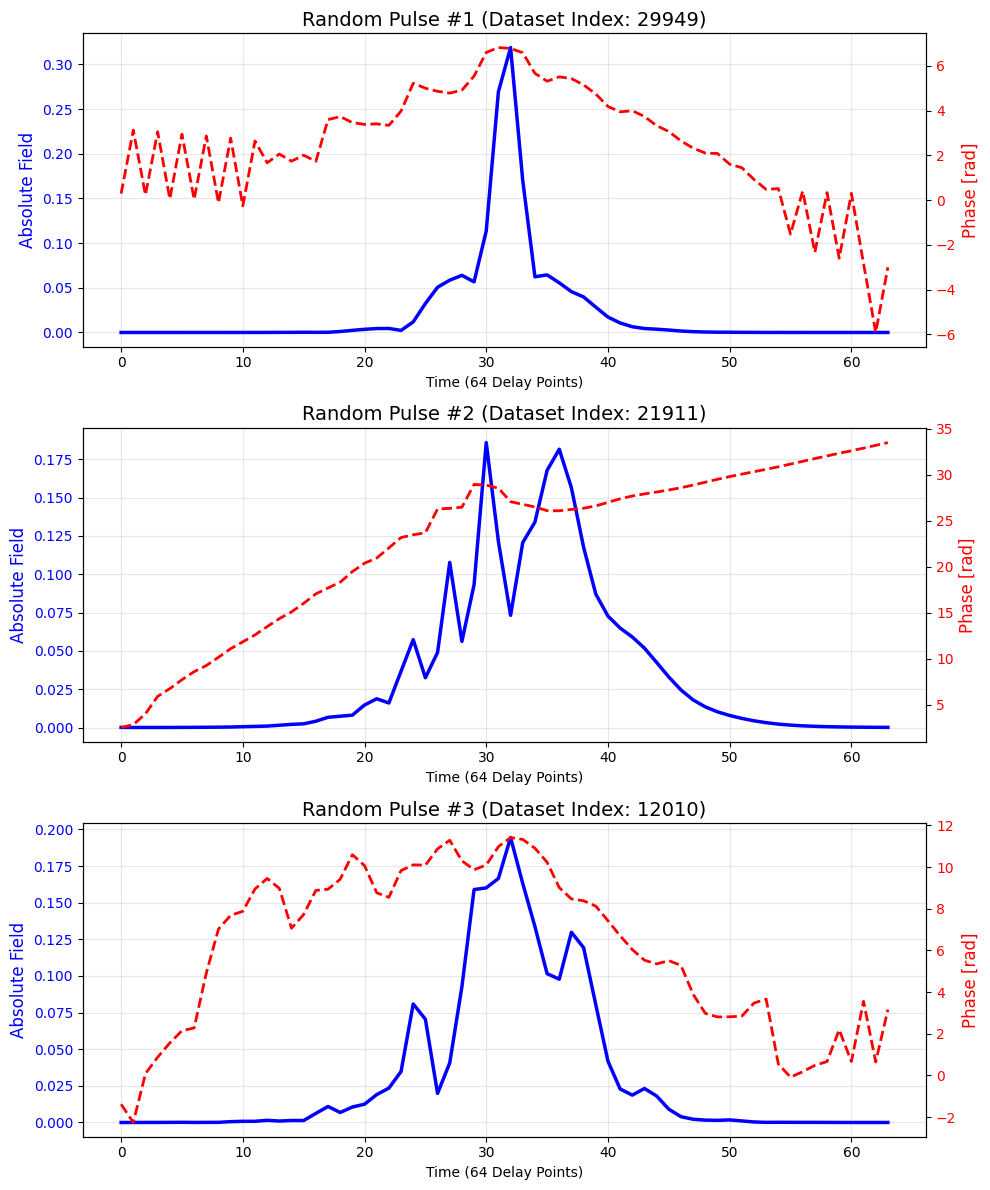

In [29]:
# ייצור הנתונים עם סיגמה 3 (ניתן להגדיל את סיגמה לקבלת פאזה חלקה אפילו יותר)
dataset = generate_pulses_gaussian(N, sigma=3)

# שליפת 3 אינדקסים אקראיים מתוך המאגר
random_indices = random.sample(range(N), 3)

# יצירת גרפים להצגת 3 הפולסים שנבחרו
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, idx in enumerate(random_indices):
    pulse = dataset[idx]

    # חישוב האמפליטודה במרחב הזמן
    amplitude = np.abs(pulse)

    # חישוב הפאזה תוך שימוש ב-unwrap כדי למנוע את קפיצות הפאזה המלאכותיות!
    phase = np.unwrap(np.angle(pulse))

    ax1 = axes[i]
    ax2 = ax1.twinx()

    # שרטוט האמפליטודה
    ax1.plot(amplitude, color='blue', linewidth=2.5, label='Absolute Field [a.u]')
    ax1.set_ylabel('Absolute Field', color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='blue')

    # שרטוט הפאזה החלקה
    ax2.plot(phase, color='red', linestyle='--', linewidth=2, label='Phase [rad]')
    ax2.set_ylabel('Phase [rad]', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.set_title(f'Random Pulse #{i+1} (Dataset Index: {idx})', fontsize=14)
    ax1.set_xlabel('Time (64 Delay Points)')
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()